###迴歸是怎麼變成分類的呢？

在線性迴歸問題中，得到了具體的迴歸值，如果此時任務做一個二分類該怎麼辦？

如果完成可以將連續的數值轉換成對應的區間，這樣就可以分類任務了，邏輯迴歸中藉助sigmoid函數完成了數值映射，透過機率值比較來完成分類任務

In [1]:
import numpy as np
import os
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

### 神奇的sigmoid函數：

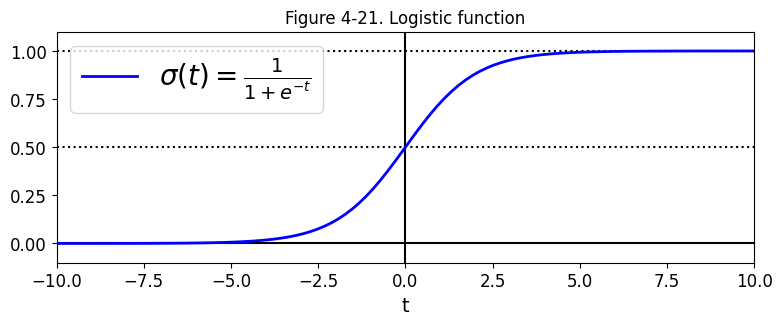

In [2]:
t = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-t))
plt.figure(figsize=(9, 3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
plt.title('Figure 4-21. Logistic function')
plt.show()

### 推導公式：
![title](./img/1.png)

###鳶尾花資料集：
![title](./img/2.png)

### 載入sklearn內建資料集

In [3]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [4]:
print (iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

對於傳統邏輯迴歸，要對標籤多變換，開啟屬於目前類別為1，其他類別為0

In [5]:
X = iris['data'][:,3:]
y = (iris['target'] == 2).astype(int)

In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [7]:
from sklearn.linear_model import LogisticRegression
log_res = LogisticRegression()
log_res.fit(X,y)

LogisticRegression()

In [8]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_res.predict_proba(X_new)

In [9]:
y_proba

array([[9.99249051e-01, 7.50949397e-04],
       [9.99239224e-01, 7.60776030e-04],
       [9.99229269e-01, 7.70731151e-04],
       ...,
       [3.08499021e-03, 9.96915010e-01],
       [3.04523414e-03, 9.96954766e-01],
       [3.00598887e-03, 9.96994011e-01]])

隨著輸入特徵數值的變化，結果機率值隨之變化

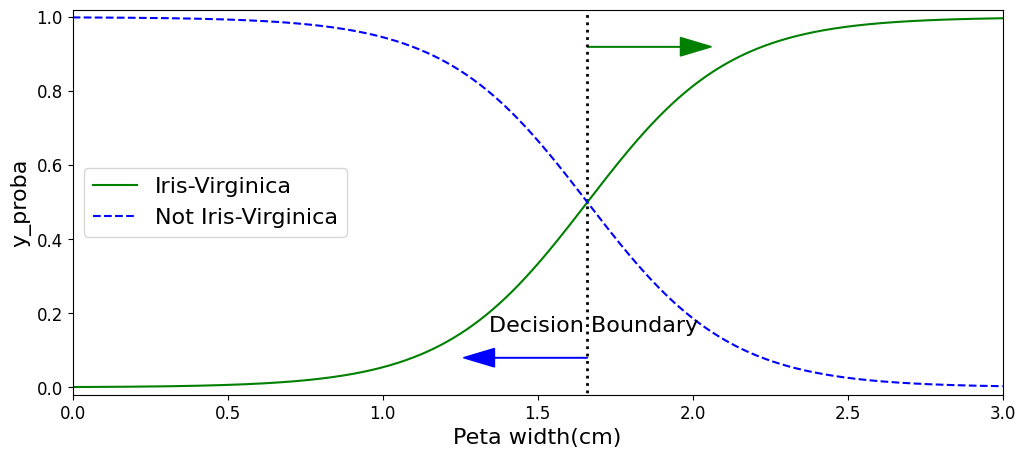

In [10]:
plt.figure(figsize=(12,5))
# 將 1x1 陣列轉成純量，避免新版 matplotlib 在 arrow/plot 報型別錯誤
decision_boundary = float(X_new[y_proba[:,1] >= 0.5][0][0])
plt.plot([decision_boundary, decision_boundary], [-1, 2], 'k:', linewidth=2)
plt.plot(X_new, y_proba[:,1], 'g-', label='Iris-Virginica')
plt.plot(X_new, y_proba[:,0], 'b--', label='Not Iris-Virginica')
plt.arrow(decision_boundary, 0.08, -0.3, 0, head_width=0.05, head_length=0.1, fc='b', ec='b')
plt.arrow(decision_boundary, 0.92, 0.3, 0, head_width=0.05, head_length=0.1, fc='g', ec='g')
plt.text(decision_boundary + 0.02, 0.15, 'Decision Boundary', fontsize=16, color='k', ha='center')
plt.xlabel('Peta width(cm)', fontsize=16)
plt.ylabel('y_proba', fontsize=16)
plt.axis([0,3,-0.02,1.02])
plt.legend(loc='center left', fontsize=16)

In [11]:
print (help(plt.arrow))

Help on function arrow in module matplotlib.pyplot:

arrow(x: 'float', y: 'float', dx: 'float', dy: 'float', **kwargs) -> 'FancyArrow'
    Add an arrow to the Axes.
    
    This draws an arrow from ``(x, y)`` to ``(x+dx, y+dy)``.
    
    Parameters
    ----------
    x, y : float
        The x and y coordinates of the arrow base.
    
    dx, dy : float
        The length of the arrow along x and y direction.
    
    width : float, default: 0.001
        Width of full arrow tail.
    
    length_includes_head : bool, default: False
        True if head is to be counted in calculating the length.
    
    head_width : float or None, default: 3*width
        Total width of the full arrow head.
    
    head_length : float or None, default: 1.5*head_width
        Length of arrow head.
    
    shape : {'full', 'left', 'right'}, default: 'full'
        Draw the left-half, right-half, or full arrow.
    
    overhang : float, default: 0
        Fraction that the arrow is swept back (0 ov

In [12]:
X = iris['data'][:,(2,3)]
y = (iris['target']==2).astype(int)

In [13]:
from sklearn.linear_model import LogisticRegression
log_res = LogisticRegression(C = 10000)
log_res.fit(X,y)

LogisticRegression(C=10000)

In [14]:
X[:,0].min(),X[:,0].max()

(np.float64(1.0), np.float64(6.9))

In [15]:
X[:,1].min(),X[:,1].max()

(np.float64(0.1), np.float64(2.5))

### 邊界決策的重要性：
- 建立座標數據，合理的範圍貿易，根據實際訓練時輸入數據來決定
- 整合座標點，取得所有測試輸入座標資料點
- 預測，得到所有點的機率值
- 等高線，完成邊界決策

建構坐標數據：

In [16]:
x0,x1 = np.meshgrid(np.linspace(1,2,2).reshape(-1,1),np.linspace(10,20,3).reshape(-1,1))

In [17]:
x0

array([[1., 2.],
       [1., 2.],
       [1., 2.]])

In [18]:
x1

array([[10., 10.],
       [15., 15.],
       [20., 20.]])

In [19]:
np.c_[x0.ravel(),x1.ravel()]

array([[ 1., 10.],
       [ 2., 10.],
       [ 1., 15.],
       [ 2., 15.],
       [ 1., 20.],
       [ 2., 20.]])

In [20]:
x0,x1 = np.meshgrid(np.linspace(2.9,7,500).reshape(-1,1),np.linspace(0.8,2.7,200).reshape(-1,1))


In [21]:
X_new = np.c_[x0.ravel(),x1.ravel()]
X_new

array([[2.9       , 0.8       ],
       [2.90821643, 0.8       ],
       [2.91643287, 0.8       ],
       ...,
       [6.98356713, 2.7       ],
       [6.99178357, 2.7       ],
       [7.        , 2.7       ]])

In [22]:
X_new.shape

(100000, 2)

In [23]:
y_proba = log_res.predict_proba(X_new)

In [24]:
x0.shape

(200, 500)

In [25]:
x1.shape

(200, 500)

Text(6.5, 2.3, 'Vir')

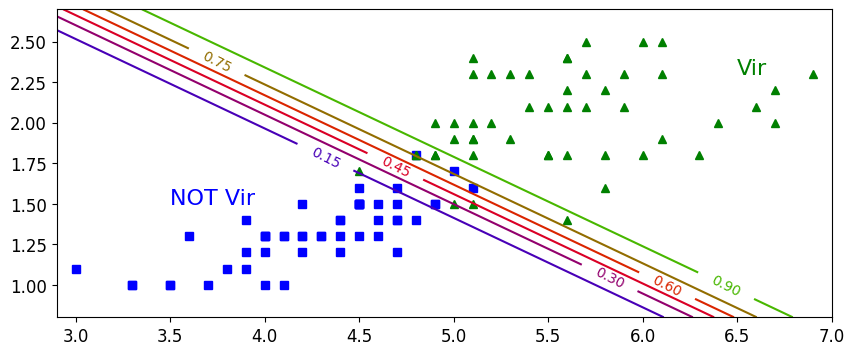

In [26]:
plt.figure(figsize=(10,4))
plt.plot(X[y==0,0],X[y==0,1],'bs')
plt.plot(X[y==1,0],X[y==1,1],'g^')

zz = y_proba[:,1].reshape(x0.shape)
contour = plt.contour(x0,x1,zz,cmap=plt.cm.brg)
plt.clabel(contour,inline = 1)
plt.axis([2.9,7,0.8,2.7])
plt.text(3.5,1.5,'NOT Vir',fontsize = 16,color = 'b')
plt.text(6.5,2.3,'Vir',fontsize = 16,color = 'g')

###如何進行多類別分類呢？ Softmax該登場了

![title](./img/3.png)

In [27]:
X = iris['data'][:,(2,3)]
y = iris['target']

In [28]:
softmax_reg = LogisticRegression(multi_class = 'multinomial',solver='lbfgs')
softmax_reg.fit(X,y)

LogisticRegression(multi_class='multinomial')

In [29]:
softmax_reg.predict([[5,2]])

array([2])

In [30]:
softmax_reg.predict_proba([[5,2]])

array([[2.43199208e-04, 2.14948752e-01, 7.84808048e-01]])

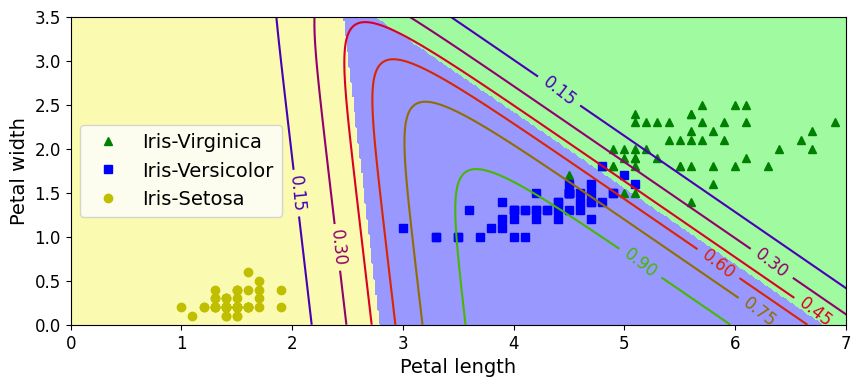

In [31]:
x0, x1 = np.meshgrid(
        np.linspace(0, 8, 500).reshape(-1, 1),
        np.linspace(0, 3.5, 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]


y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y==2, 0], X[y==2, 1], "g^", label="Iris-Virginica")
plt.plot(X[y==1, 0], X[y==1, 1], "bs", label="Iris-Versicolor")
plt.plot(X[y==0, 0], X[y==0, 1], "yo", label="Iris-Setosa")

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap=plt.cm.brg)
plt.clabel(contour, inline=1, fontsize=12)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 7, 0, 3.5])
plt.show()